In [132]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/airline-delay-cause/Airline_Delay_Cause.csv')

df = df.dropna(subset=['year',
                       'month',
                       'arr_flights',
                       'airport'])
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))


subset = df[['date','arr_flights','airport']]

subset.set_index('date', inplace=True)

df.head()


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,date
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0,2022-05-01
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0,2022-05-01
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0,2022-05-01
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0,2022-05-01
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0,2022-05-01


# **Mean of Fligts across time**

Create a real mean of lights by month

Text(0.5, 1.0, 'Average Annual Flight Arrivals (2003–2022)')

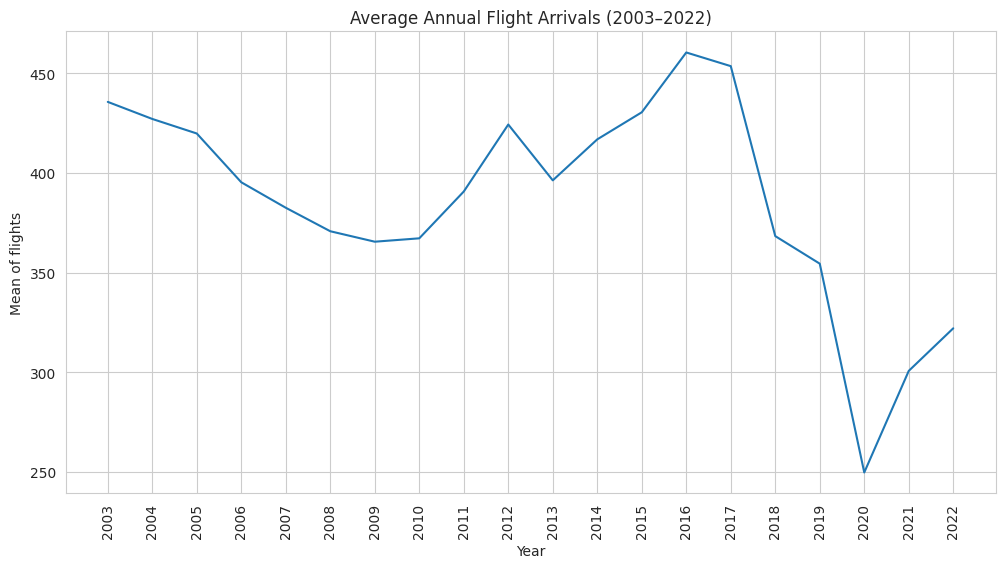

In [130]:
meanFlights = df[['year','arr_flights']]

meanFlights = meanFlights.groupby('year')['arr_flights'].mean()



plt.figure(figsize=(12, 6))

sns.set_style("whitegrid")

sns.lineplot(data=meanFlights)

plt.xticks(meanFlights.index, rotation=90)


plt.xlabel("Year")
plt.ylabel("Mean of flights")
plt.title("Average Annual Flight Arrivals (2003–2022)")

## **Flight Volume Trends**


Text(0, 0.5, 'Flights')

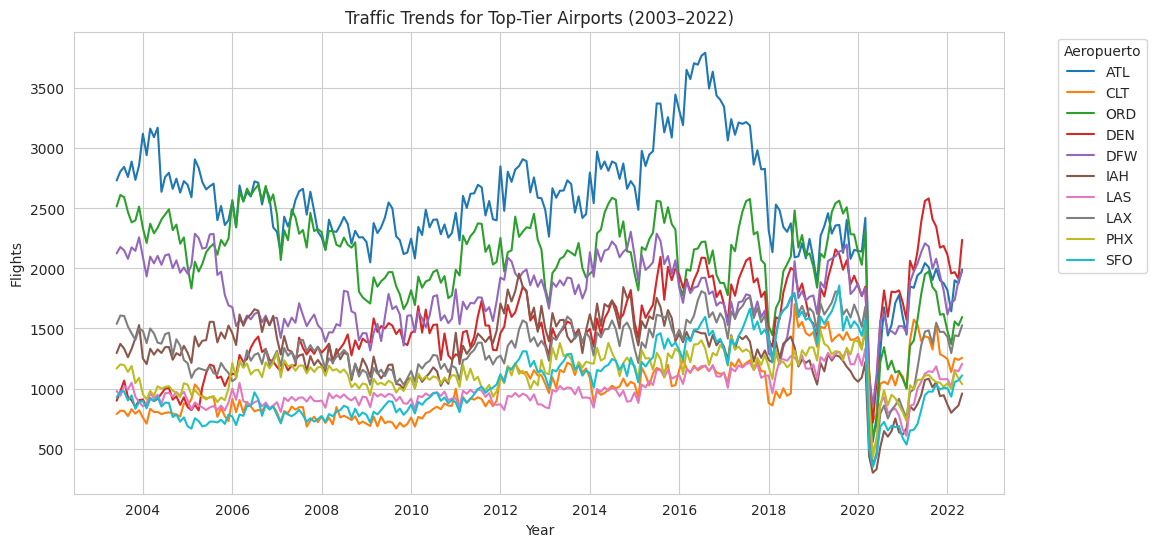

In [134]:

top5 = subset.groupby('airport')['arr_flights'].sum().sort_values(ascending=False).head(10).index.tolist()

subsettop5 = subset[subset['airport'].isin(top5)]

plt.figure(figsize=(12, 6))
plt.title("Traffic Trends for Top-Tier Airports (2003–2022)")

sns.lineplot(data=subsettop5, x=subsettop5.index, y='arr_flights', hue='airport', errorbar=None)

plt.legend(title='Aeropuerto', bbox_to_anchor=(1.05, 1), loc='best')
plt.xlabel("Year")
plt.ylabel("Flights")


## **Seasonal Flight Volume Trends**

Text(0, 0.5, 'Flights')

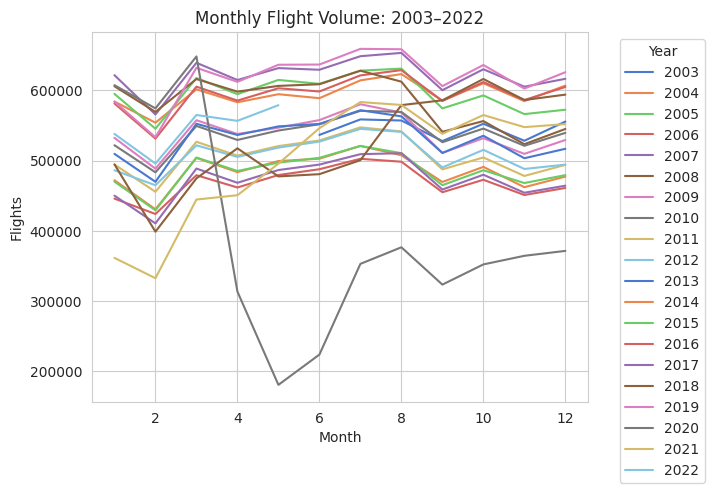

In [98]:
seassonFlights = df[['year', 'month', 'arr_flights']]


flightsYear= seassonFlights.groupby(['year', 'month'])['arr_flights'].sum().to_frame()

sns.lineplot(data=flightsYear, x='month' , y='arr_flights', hue='year',palette="muted", errorbar=None)

plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='best')
plt.title("Monthly Flight Volume: 2003–2022")
plt.xlabel("Month")
plt.ylabel("Flights")


Text(0, 0.5, 'Flights')

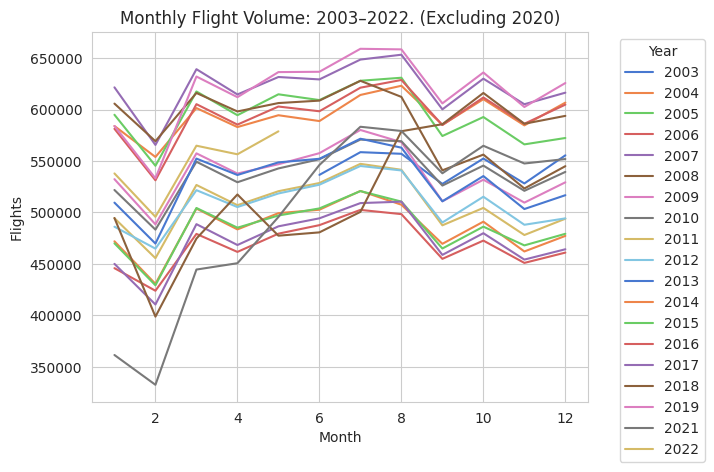

In [99]:
flightsYear = df.groupby(['year', 'month'])['arr_flights'].sum().reset_index()

wo2022Flights = flightsYear[flightsYear['year']!= 2020 ]

sns.lineplot(data=wo2022Flights, x='month' , y='arr_flights', hue='year',palette="muted", errorbar=None)

plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='best')
plt.title("Monthly Flight Volume: 2003–2022. (Excluding 2020)")
plt.xlabel("Month")
plt.ylabel("Flights")

## **Best years seasonal fligh volume**

Text(0, 0.5, 'Flights')

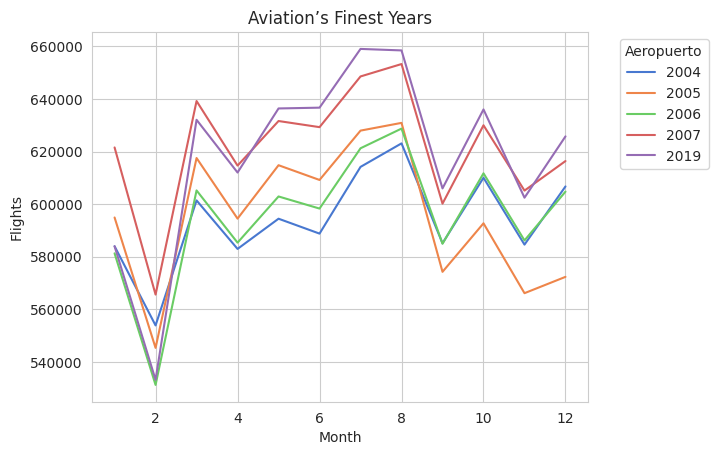

In [100]:
bestYear = flightsYear.groupby('year')['arr_flights'].sum().nlargest(5).index

BestflightsYear = flightsYear[flightsYear['year'].isin(bestYear)]


BestflightsYear

sns.lineplot(data= BestflightsYear, x='month', y='arr_flights', hue= 'year', palette="muted", errorbar=None)

plt.legend(title='Aeropuerto', bbox_to_anchor=(1.05, 1), loc='best')
plt.title("Aviation’s Finest Years")
plt.xlabel("Month")
plt.ylabel("Flights")


## **Top 10 airports by Flight Volume**



Text(0, 0.5, 'Airport')

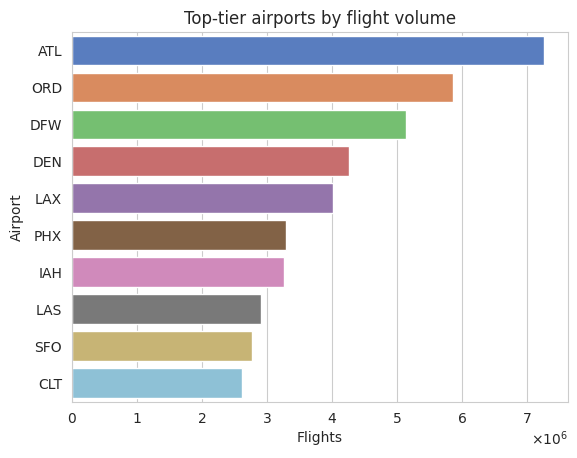

In [120]:
sumFlights = subset.groupby('airport')['arr_flights'].sum().sort_values(ascending = False).to_frame()

top10 = sumFlights.head(10)

sns.barplot(x=top10['arr_flights'],  y= top10.index, hue=top10.index,  palette="muted")

plt.gca().ticklabel_format(axis='x', style='sci', scilimits=(0,0), useMathText=True)
plt.title("Top-tier airports by flight volume")

plt.xlabel("Flights")
plt.ylabel("Airport")

# **Total Delay Minutes by Cause**

Text(0.5, 1.0, 'Total delay minutes by cause')

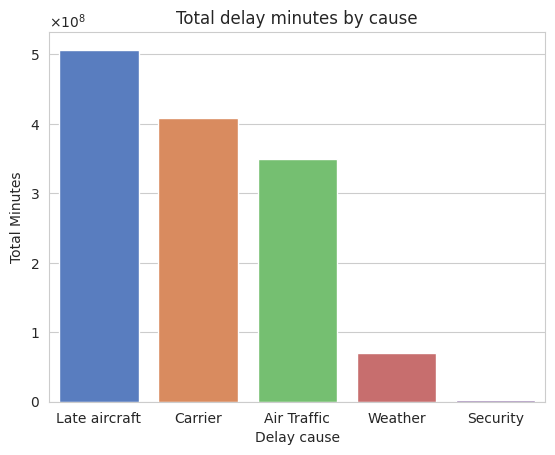

In [122]:
totalDelay = df.dropna(subset = ['weather_delay','nas_delay','security_delay','late_aircraft_delay'])

totalDelay = totalDelay[['carrier_delay',
                         'weather_delay',
                         'nas_delay',
                         'security_delay',
                        'late_aircraft_delay']].sum().sort_values(ascending = False).to_frame()

totalDelay = totalDelay.rename(index = { 'carrier_delay': 'Carrier',
                                        'weather_delay':'Weather',
                                        'nas_delay':'Air Traffic',
                                        'security_delay': 'Security',
                                       'late_aircraft_delay':'Late aircraft'})

totalDelay = totalDelay.rename(columns = { 0 :'TotalMinutes'})

sns.barplot(data=totalDelay, y='TotalMinutes', x=totalDelay.index, palette="muted", hue=totalDelay.index, legend=False)

plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)


plt.xlabel("Delay cause")
plt.ylabel("Total Minutes")

plt.title("Total delay minutes by cause")




# **Correlation Matrix of Delay Types**



<Axes: >

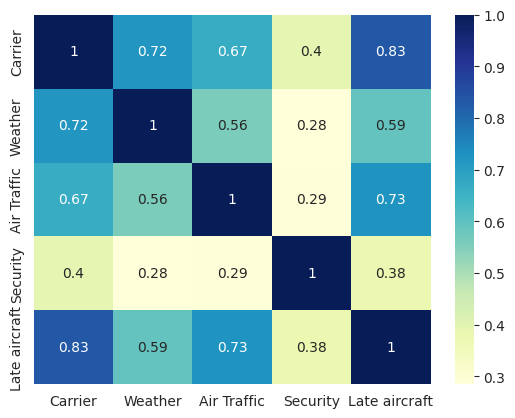

In [103]:
subCorrDelays = df[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']]

subCorrDelays = subCorrDelays.rename(columns = { 'carrier_delay': 'Carrier',
                                        'weather_delay':'Weather',
                                        'nas_delay':'Air Traffic',
                                        'security_delay': 'Security',
                                       'late_aircraft_delay':'Late aircraft'})

subCorr = subCorrDelays.corr()

sns.heatmap(data=subCorr,cmap="YlGnBu", annot=True)

plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)


<Axes: xlabel='Carrier', ylabel='Late aircraft'>

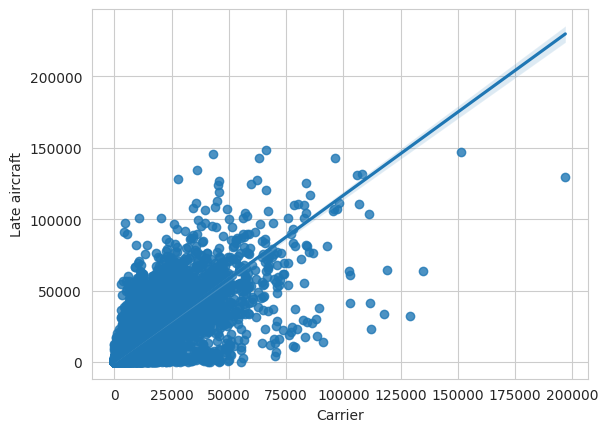

In [104]:
sns.regplot(x=subCorrDelays['Carrier'] ,y=subCorrDelays['Late aircraft'])

plt.title("Regrsion ")

# **Monthly Delay Cause Intensity**

Text(120.72222222222221, 0.5, 'Year Month')

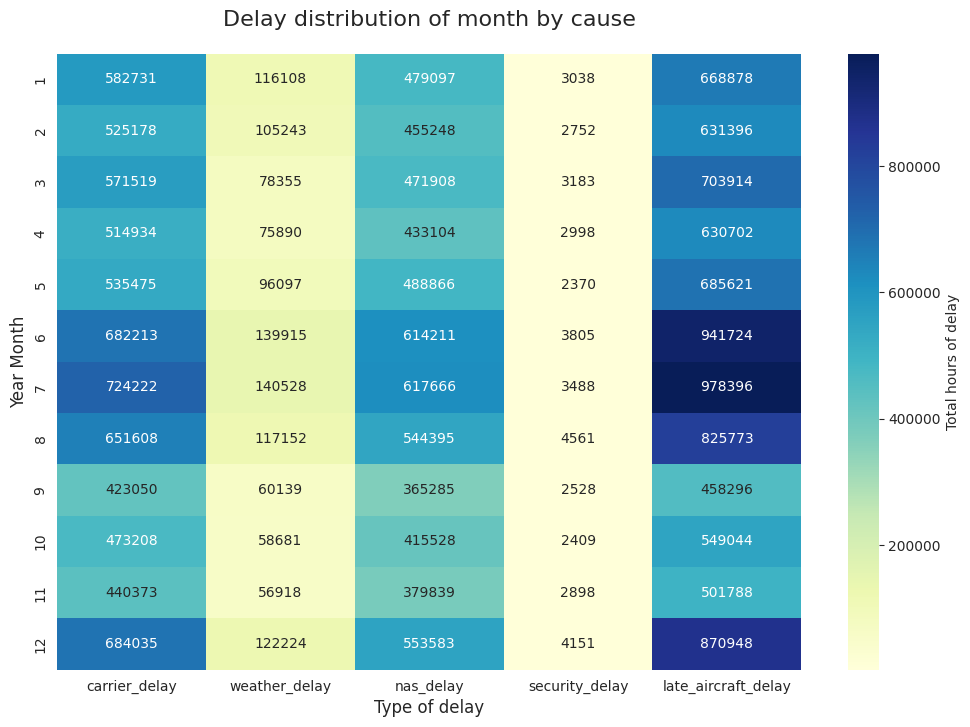

In [123]:
subDelayMonth = df[['month','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']]

subDelayMonth = subDelayMonth.groupby('month')[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].sum()

subDelayMonth = subDelayMonth/60


plt.figure(figsize=(12, 8))

sns.heatmap(data=subDelayMonth, 
            annot=True, 
            fmt='.0f',
            cmap="YlGnBu",
            cbar_kws={'label': 'Total hours of delay'})

plt.title('Delay distribution of month by cause', fontsize=16, pad=20)
plt.xlabel('Type of delay', fontsize=12)
plt.ylabel('Year Month', fontsize=12)

# **Monthly Delay Cause Intensity( 2019- Bussiest year)**

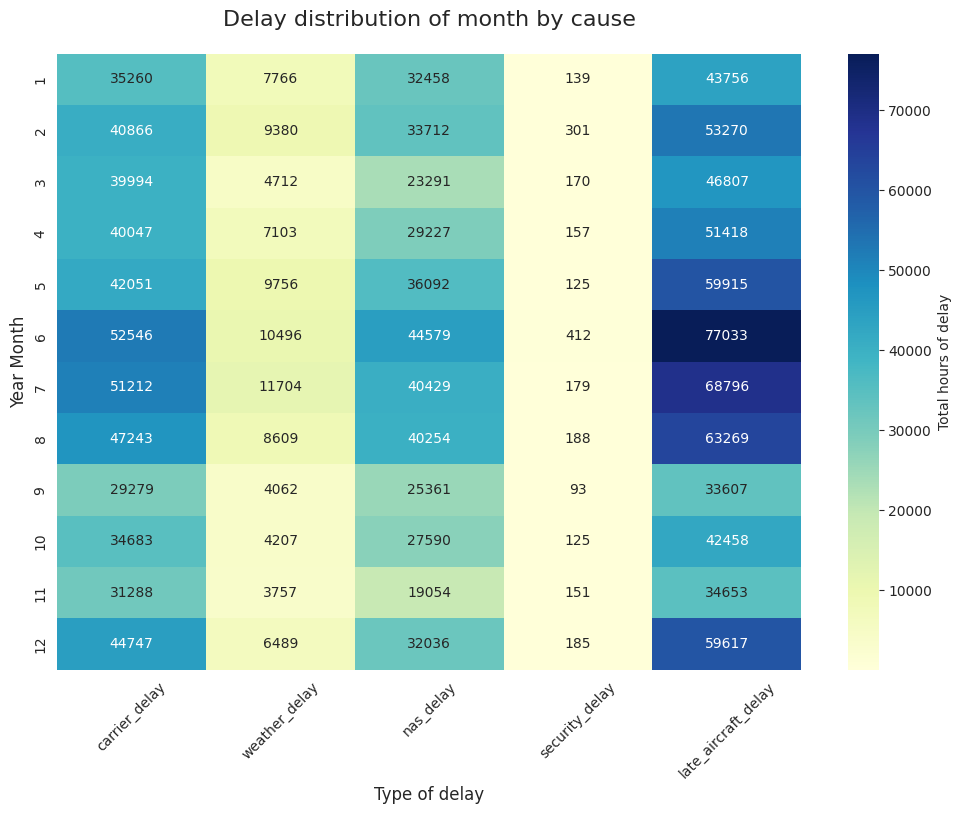

In [106]:
bestDelayCorr = df[['year','month','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']]

bestDelayCorr = bestDelayCorr[bestDelayCorr['year'] == 2019]

bestDelayCorr = bestDelayCorr[['month','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']]

bestDelayCorr = bestDelayCorr.groupby('month')[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].sum()

bestDelayCorr = bestDelayCorr/60

plt.figure(figsize=(12, 8))

sns.heatmap(data=bestDelayCorr, 
            annot=True, 
            fmt='.0f',
            cmap="YlGnBu",
            cbar_kws={'label': 'Total hours of delay'})

plt.title('Delay distribution of month by cause', fontsize=16, pad=20)
plt.xlabel('Type of delay', fontsize=12)
plt.ylabel('Year Month', fontsize=12)

plt.xticks(rotation=45)

plt.show()


## **Delay acrros time by airport**

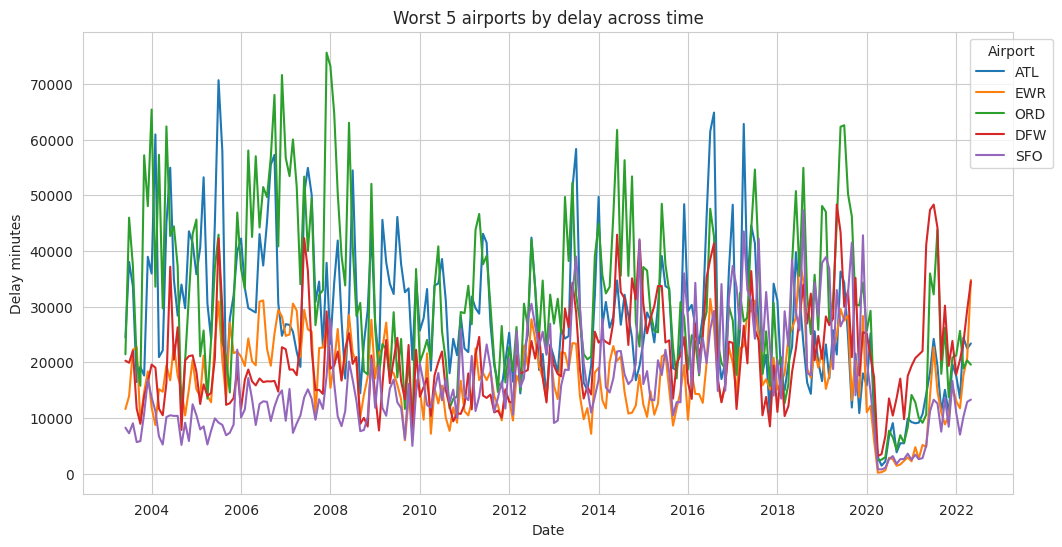

In [107]:
setArrDelay = df[['date','airport','arr_delay',]]

setArrDelay.set_index('date', inplace=True)

top5ArrDelay = setArrDelay.groupby('airport')['arr_delay'].sum().sort_values(ascending=False).head(5).index.tolist()


subsettop5ArrD = setArrDelay[setArrDelay['airport'].isin(top5ArrDelay)]

plt.figure(figsize=(12, 6))
plt.title("Worst 5 airports by delay across time")

sns.lineplot(data=subsettop5ArrD, x=subsettop5ArrD.index, y='arr_delay', hue='airport', errorbar=None)

plt.legend(title='Airport', bbox_to_anchor=(1.05, 1), loc='best')
plt.xlabel("Date")
plt.ylabel("Delay minutes")
plt.show()

## **Total delay by airport**

Group by airport, sum arr_delay 

Text(0, 0.5, 'Airport')

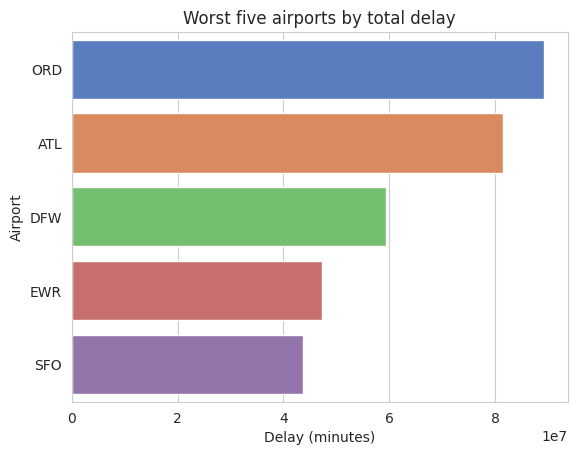

In [108]:

sumDelayTop10 = setArrDelay.groupby('airport')['arr_delay'].sum().sort_values(ascending = False).to_frame().head(5)

sns.barplot(data=sumDelayTop10, y=sumDelayTop10.index, x="arr_delay", palette="muted", hue=sumDelayTop10.index, legend=False)

plt.title("Worst five airports by total delay")
plt.xlabel("Delay (minutes)")
plt.ylabel("Airport")




# **Cancellations by Airline**

Group canvelations by arline sum 

Text(0, 0.5, 'Cancelations')

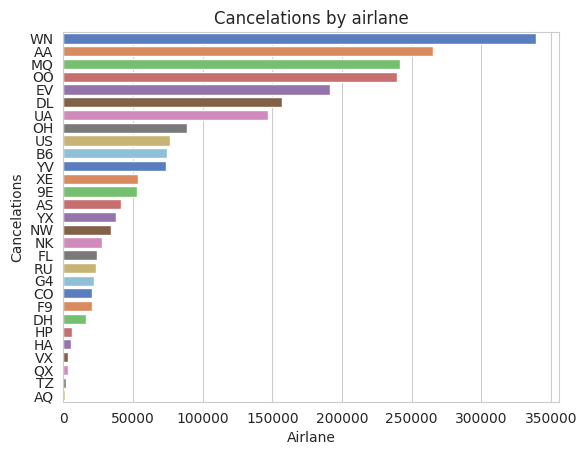

In [109]:
setCacelAir = df.dropna(subset = ['carrier', 'carrier_name', 'arr_cancelled'])

setCacelAir = df[['carrier', 'carrier_name', 'arr_cancelled']]

setCacelAir = setCacelAir.groupby("carrier")['arr_cancelled'].sum().sort_values(ascending = False).to_frame()


sns.barplot(data=setCacelAir,x='arr_cancelled', y='carrier', palette="muted", hue=setCacelAir.index, legend=False)

plt.title("Cancelations by airlane")
plt.xlabel("Airlane")
plt.ylabel("Cancelations")

## **Worst airlanes by cancelations**

Text(0, 0.5, 'Cancelations')

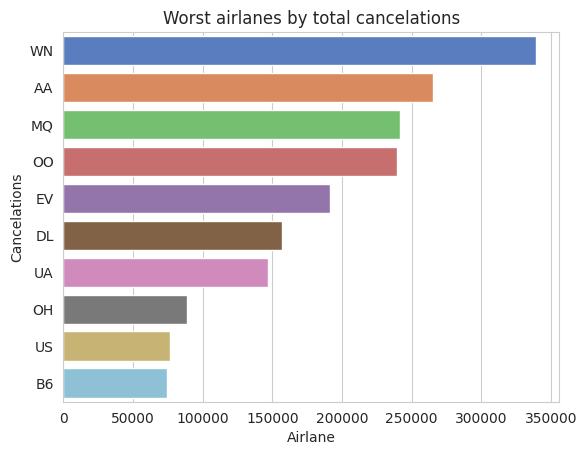

In [110]:
top10setCacelAir = setCacelAir.head(10)

sns.barplot(data=top10setCacelAir,x='arr_cancelled', y='carrier', palette="muted", hue=top10setCacelAir.index, legend=False)

plt.title("Worst airlanes by total cancelations")
plt.xlabel("Airlane")
plt.ylabel("Cancelations")

## **Best airlanes by cancelations**

Text(0, 0.5, 'Cancelations')

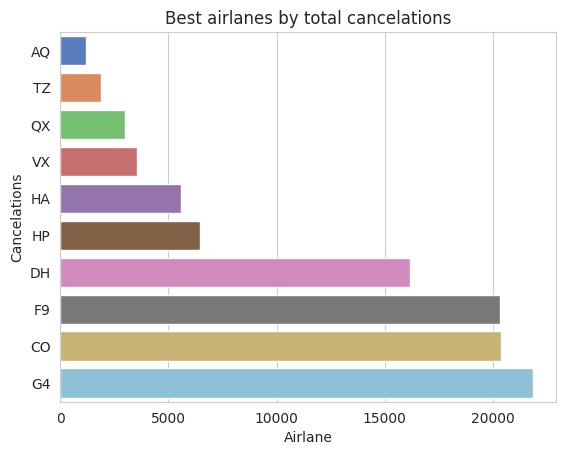

In [111]:
bottom10setCacelAir = setCacelAir.tail(10).sort_values(by="arr_cancelled", ascending=True)

sns.barplot(data=bottom10setCacelAir,x='arr_cancelled', y='carrier', palette="muted", hue=bottom10setCacelAir.index, legend=False)

plt.title("Best airlanes by total cancelations")
plt.xlabel("Airlane")
plt.ylabel("Cancelations")